# Olink NPX simulator — end-to-end demo

This notebook walks through [`synthlab.olink.simulate_olink_npx`](../synthlab/olink.py)
— a minimal, dependency-light simulator for [Olink](https://olink.com)-style NPX
(Normalized Protein eXpression) proteomics data. As of 2026-04 there is no
widely-used open-source Olink simulator; the closest analogues are
[MSstatsSampleSize](https://bioconductor.org/packages/MSstatsSampleSize/)
(LC-MS/MS, not NPX) and the [OlinkAnalyze R
package](https://github.com/Olink-Proteomics/OlinkRPackage), which ships demo
tables but no generative simulator.

The model implemented in [`synthlab/olink.py`](../synthlab/olink.py) is deliberately
minimal and covers the three features needed to exercise downstream ML /
biomarker-discovery pipelines:

- Per-protein NPX ~ N(mean, sd) draws with user-configurable **group-mean
  shifts** (the "biomarker" signal).
- **Limit-of-detection (LOD)** driven missingness: 80% of sub-LOD values are
  dropped (MNAR), 20% are retained and can be flagged with `qc_warning`.
- **Per-plate batch effects** — 96 samples / plate, plate intercepts drawn
  from N(0, `plate_effect_sd`^2).

Deferred to follow-up PRs: full MAR missingness, multi-factor batch effects,
panel-version LOD bridging, and a realistic PEA dilution noise model. See
[PR #2](https://github.com/bschilder/synthlab/pull/2) for the roadmap.

**Install extras for this notebook** (`matplotlib`, `seaborn`, `scikit-learn`,
`umap-learn`):

```bash
pip install synthlab[viz]
```

## 2. Minimal generate + peek

Draw 500 samples split 250/250 case/control, with three manually-injected
biomarkers (CRP, IL6, TNF). We use the built-in 50-protein
[`default_explore_3072_panel`](../synthlab/olink.py) — a UKB-PPP-informed subset
of the Olink Explore 3072 panel.

In [1]:
# NOTE: only the `viz` extra is required in addition to core deps.
import warnings

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 100

RNG_SEED = 42

In [2]:
from synthlab import (
    OlinkSimConfig,
    default_explore_3072_panel,
    simulate_olink_npx,
)

panel = default_explore_3072_panel()
cfg = OlinkSimConfig(
    n_samples=500,
    panel=panel,
    group_effects={
        "CRP": {"case": 1.8},
        "IL6": {"case": 1.2},
        "TNF": {"case": 0.9},
    },
    group_assignments=["case"] * 250 + ["control"] * 250,
    seed=RNG_SEED,
)
df = simulate_olink_npx(cfg)
df.head(10)

[04/23/26 17:12:48] INFO     Loading faiss.                                                           ]8;id=1719918;file:///Users/bschilder/Desktop/smb-protopheno/.pixi/envs/dev/lib/python3.11/site-packages/faiss/loader.py\loader.py]8;;\:]8;id=1719919;file:///Users/bschilder/Desktop/smb-protopheno/.pixi/envs/dev/lib/python3.11/site-packages/faiss/loader.py#148\148]8;;\

                    INFO     Successfully loaded faiss.                                               ]8;id=1719925;file:///Users/bschilder/Desktop/smb-protopheno/.pixi/envs/dev/lib/python3.11/site-packages/faiss/loader.py\loader.py]8;;\:]8;id=1719926;file:///Users/bschilder/Desktop/smb-protopheno/.pixi/envs/dev/lib/python3.11/site-packages/faiss/loader.py#150\150]8;;\

                    INFO     Failed to load GPU Faiss: name 'GpuIndexIVFFlat' is not defined. Will  ]8;id=1719933;file:///Users/bschilder/Desktop/smb-protopheno/.pixi/envs/dev/lib/python3.11/site-packages/faiss/__init__.py\__init__.py]8;;\:]8;id=1719934;file:///Users/bschilder/Desktop/smb-protopheno/.pixi/envs/dev/lib/python3.11/site-packages/faiss/__init__.py#173\173]8;;\
                             not load constructor refs for GPU indexes.                                            


  ░██████╗██╗░░░██╗███╗░░██╗████████╗██╗░░██╗  ██╗░░░░░░█████╗░██████╗░
  ██╔════╝╚██╗░██╔╝████╗░██║╚══██╔══╝██║░░██║  ██║░░░░░██╔══██╗██╔══██╗
  ╚█████╗░░╚████╔╝░██╔██╗██║░░░██║░░░███████║  ██║░░░░░███████║██████╦╝
  ░╚═══██╗░░╚██╔╝░░██║╚████║░░░██║░░░██╔══██║  ██║░░░░░██╔══██║██╔══██╗
  ██████╔╝░░░██║░░░██║░╚███║░░░██║░░░██║░░██║  ███████╗██║░░██║██████╦╝
  ╚═════╝░░░░╚═╝░░░╚═╝░░╚══╝░░░╚═╝░░░╚═╝░░╚═╝  ╚══════╝╚═╝░░╚═╝╚═════╝░
        ▌║█║▌│║▌│║▌║▌█║▌║█║▌│║▌│║▌║▌█║▌║█║▌│║▌│║▌║▌█║▌│║▌│║▌║▌█║
  ════════════════════════════════════════════════════════════════════
  Synthetic Healthcare Data Toolkit
  ────────────────────────────────────────────────────────────────────
  ◈ EHR        Synthetic patient records (diagnoses, meds, labs)
  ◈ Genomics   Synthetic genotypes with realistic LD structure
  ◈ Imaging    Datasets + synthetic generation (CT, MRI, X-ray)
  ◈ Multimodal Linked EHR + Imaging + Genomics per patient
  ◈ AI Notes   SOAP notes with causal graph analysis
  ══════════════════

sample_id,protein_id,npx,qc_warning,group,plate_id
str,str,f64,bool,str,str
"""S0000""","""CRP""",6.922412,false,"""case""","""plate_0"""
"""S0000""","""IL6""",6.055962,false,"""case""","""plate_0"""
"""S0000""","""TNF""",5.935627,false,"""case""","""plate_0"""
"""S0000""","""IL1B""",4.533881,false,"""case""","""plate_0"""
"""S0000""","""IL10""",5.573346,false,"""case""","""plate_0"""
"""S0000""","""IL8""",5.512383,false,"""case""","""plate_0"""
"""S0000""","""IFNG""",5.085326,false,"""case""","""plate_0"""
"""S0000""","""BNP""",5.326213,false,"""case""","""plate_0"""
"""S0000""","""NT-proBNP""",4.530132,false,"""case""","""plate_0"""


In [3]:
df.describe()

statistic,sample_id,protein_id,npx,qc_warning,group,plate_id
str,str,str,f64,f64,str,str
"""count""","""23737""","""23737""",23737.0,23737.0,"""23737""","""23737"""
"""null_count""","""0""","""0""",0.0,0.0,"""0""","""0"""
"""mean""",null,null,5.009621,0.010995,null,null
"""std""",null,null,0.661795,null,null,null
"""min""","""S0000""","""AB40""",2.726476,0.0,"""case""","""plate_0"""
"""25%""",null,null,4.569688,null,null,null
"""50%""",null,null,4.992854,null,null,null
"""75%""",null,null,5.424174,null,null,null
"""max""","""S0499""","""VWF""",8.448766,1.0,"""control""","""plate_5"""


In [4]:
# Frame schema + size + row-count + missingness summary.
n_samples = 500
n_proteins = len(panel.proteins)
n_expected = n_samples * n_proteins
n_observed = df.height
drop_rate = 1.0 - n_observed / n_expected

print(f"schema            : {dict(df.schema)}")
print(f"rows              : {n_observed:,} / {n_expected:,} possible")
print(f"overall drop rate : {drop_rate:.2%}")
print(f"unique samples    : {df['sample_id'].n_unique()}")
print(f"unique proteins   : {df['protein_id'].n_unique()}")
print(f"unique plates     : {df['plate_id'].n_unique()}")
print(f"qc_warning rate   : {df['qc_warning'].mean():.2%}")

schema            : {'sample_id': String, 'protein_id': String, 'npx': Float64, 'qc_warning': Boolean, 'group': String, 'plate_id': String}
rows              : 23,737 / 25,000 possible
overall drop rate : 5.05%
unique samples    : 500
unique proteins   : 50
unique plates     : 6
qc_warning rate   : 1.10%


## 3. Per-protein NPX distributions

A 4x4 grid of NPX histograms for a representative slice of the panel. Case
(orange) vs control (blue) KDEs are overlaid; the red dashed line marks each
protein's LOD. Proteins with a non-zero `group_effects` entry are annotated
with their injected mean shift.

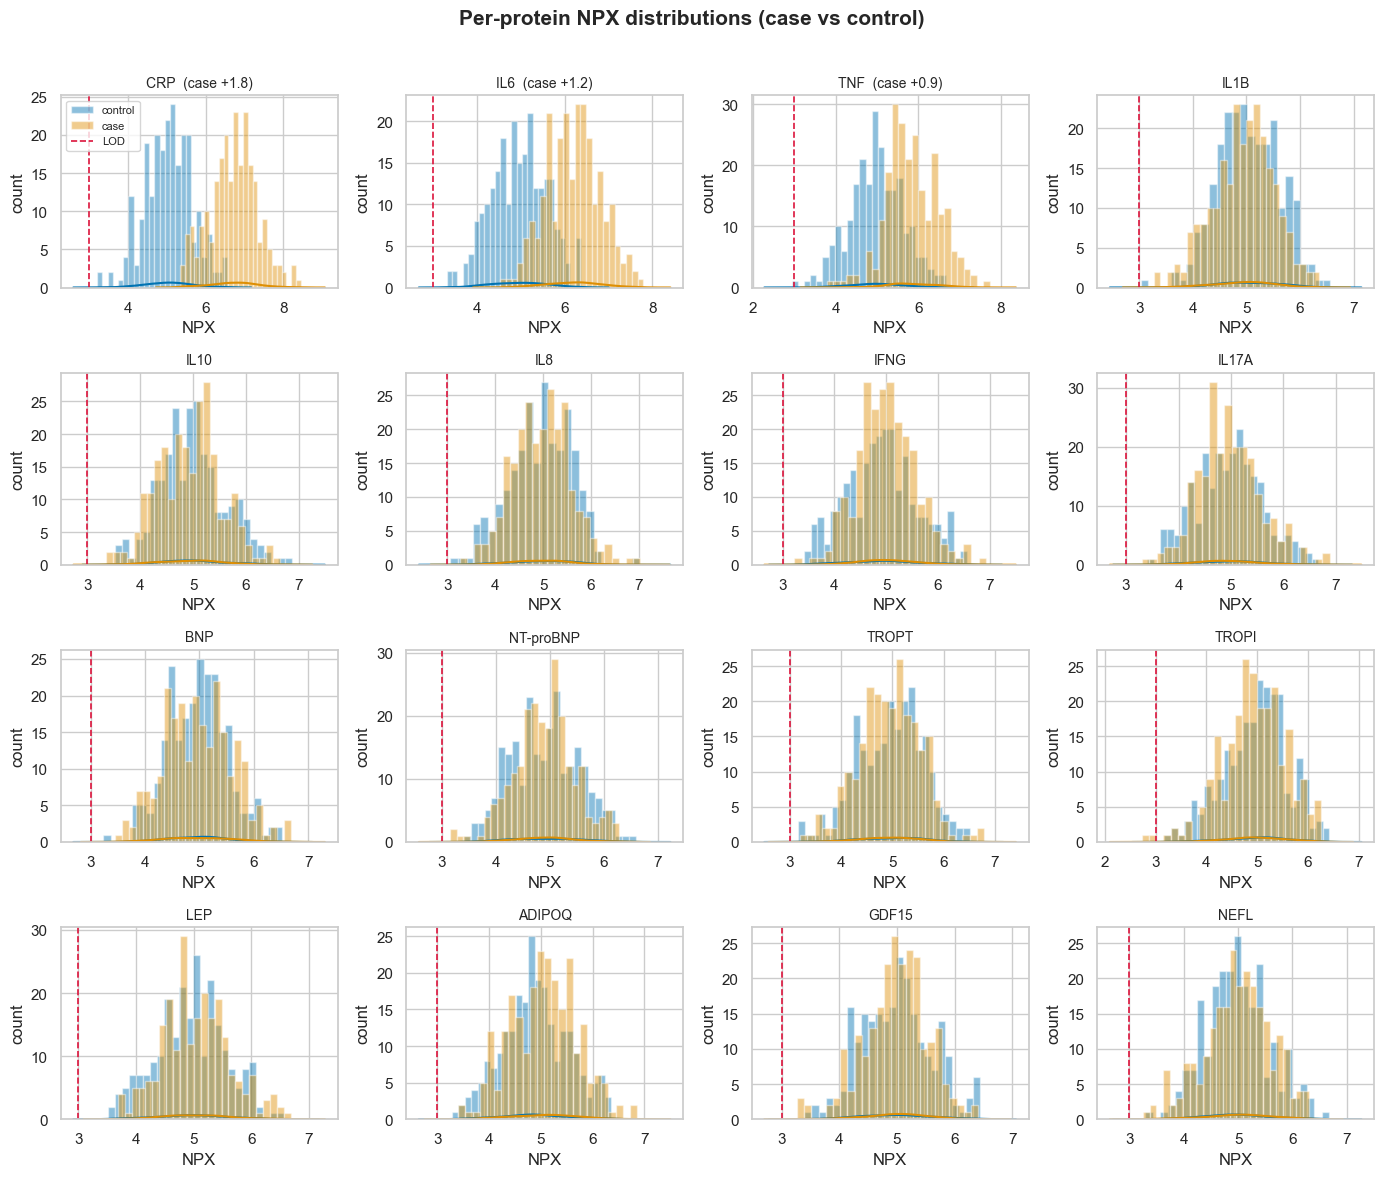

In [5]:
# Focus on a mix of injected biomarkers (first 3) plus 13 unrelated proteins.
display_proteins = ["CRP", "IL6", "TNF"] + [
    p for p in panel.proteins if p not in {"CRP", "IL6", "TNF"}
][:13]
group_shifts = {"CRP": 1.8, "IL6": 1.2, "TNF": 0.9}

fig, axes = plt.subplots(4, 4, figsize=(14, 12), sharex=False, sharey=False)
fig.suptitle(
    "Per-protein NPX distributions (case vs control)",
    fontsize=15,
    fontweight="bold",
)

palette = sns.color_palette("colorblind", 2)
for ax, prot in zip(axes.flat, display_proteins):
    sub = df.filter(pl.col("protein_id") == prot)
    for (grp, color) in zip(["control", "case"], palette):
        vals = sub.filter(pl.col("group") == grp)["npx"].to_numpy()
        if vals.size == 0:
            continue
        ax.hist(vals, bins=25, alpha=0.45, color=color, label=grp)
        sns.kdeplot(vals, ax=ax, color=color, linewidth=1.5)
    ax.axvline(panel.lod[prot], color="crimson", linestyle="--", linewidth=1.2,
               label="LOD")
    shift = group_shifts.get(prot)
    title = f"{prot}" if shift is None else f"{prot}  (case +{shift})"
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("NPX")
    ax.set_ylabel("count")
axes.flat[0].legend(loc="upper left", fontsize=8)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## 4. LOD-driven missingness

The `mnar_lod` missingness model in
[`simulate_olink_npx`](../synthlab/olink.py) drops 80% of sub-LOD values and
retains the remaining 20% (which downstream pipelines would flag with
`qc_warning`). On top of LOD dropout, a small MCAR pass removes
`missing_rate` (default 5%) of the survivors.

**Left:** per-protein mean NPX vs LOD, coloured by observed drop rate. The
closer a protein's mean is to its LOD, the larger its drop rate.
**Right:** top-20 most-dropped proteins, with rate bars.

In [6]:
per_protein = (
    df.group_by("protein_id")
      .agg(observed_mean=pl.col("npx").mean(),
           n_observed=pl.col("npx").len())
      .with_columns(
          drop_rate=1.0 - pl.col("n_observed") / n_samples,
          lod=pl.col("protein_id").map_elements(
              lambda p: panel.lod[p], return_dtype=pl.Float64),
          prior_mean=pl.col("protein_id").map_elements(
              lambda p: panel.mean[p], return_dtype=pl.Float64),
      )
      .sort("drop_rate", descending=True)
)
per_protein.head(5)

protein_id,observed_mean,n_observed,drop_rate,lod,prior_mean
str,f64,u32,f64,f64,f64
"""GHRL""",4.923021,464,0.072,3.0,5.0
"""HGF""",4.933904,467,0.066,3.0,5.0
"""FABP4""",4.977609,468,0.064,3.0,5.0
"""IGF1""",4.980917,468,0.064,3.0,5.0
"""TROPT""",4.948568,468,0.064,3.0,5.0


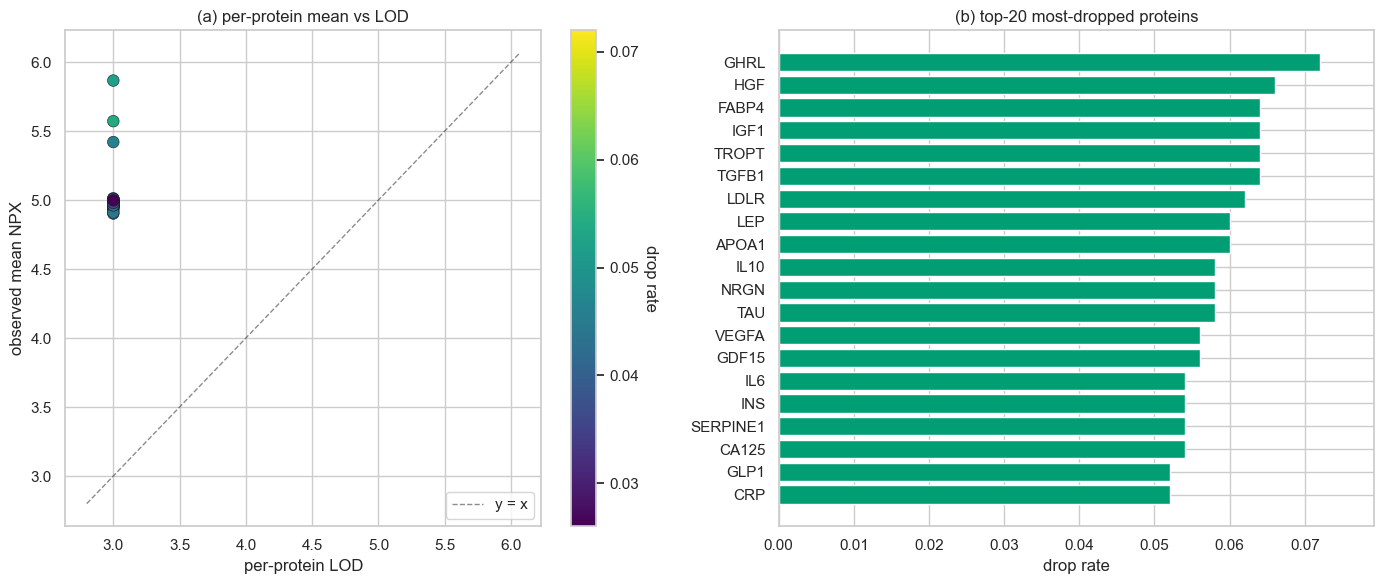

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- (a) observed mean vs LOD, coloured by drop rate ------------------------
pp = per_protein.to_pandas()
sc = ax1.scatter(
    pp["lod"], pp["observed_mean"],
    c=pp["drop_rate"], cmap="viridis", s=70, edgecolor="k",
    linewidth=0.4,
)
lo = min(pp["lod"].min(), pp["observed_mean"].min()) - 0.2
hi = max(pp["lod"].max(), pp["observed_mean"].max()) + 0.2
ax1.plot([lo, hi], [lo, hi], "k--", linewidth=1, alpha=0.5, label="y = x")
cbar = plt.colorbar(sc, ax=ax1)
cbar.set_label("drop rate", rotation=270, labelpad=14)
ax1.set_xlabel("per-protein LOD")
ax1.set_ylabel("observed mean NPX")
ax1.set_title("(a) per-protein mean vs LOD")
ax1.legend(loc="lower right")

# --- (b) top-20 most-dropped proteins ---------------------------------------
top20 = per_protein.head(20).to_pandas()
ax2.barh(top20["protein_id"][::-1], top20["drop_rate"][::-1],
         color=sns.color_palette("colorblind")[2])
ax2.set_xlabel("drop rate")
ax2.set_title("(b) top-20 most-dropped proteins")
ax2.set_xlim(0, max(top20["drop_rate"].max() * 1.1, 0.05))

fig.tight_layout()
plt.show()

## 5. Plate batch effects

With 500 samples at 96 per plate we get 6 plates; each plate gets an
intercept drawn from N(0, `plate_effect_sd`^2). The violin plot shows that
CRP still separates case vs control *within* each plate, despite the
plate-level offset.

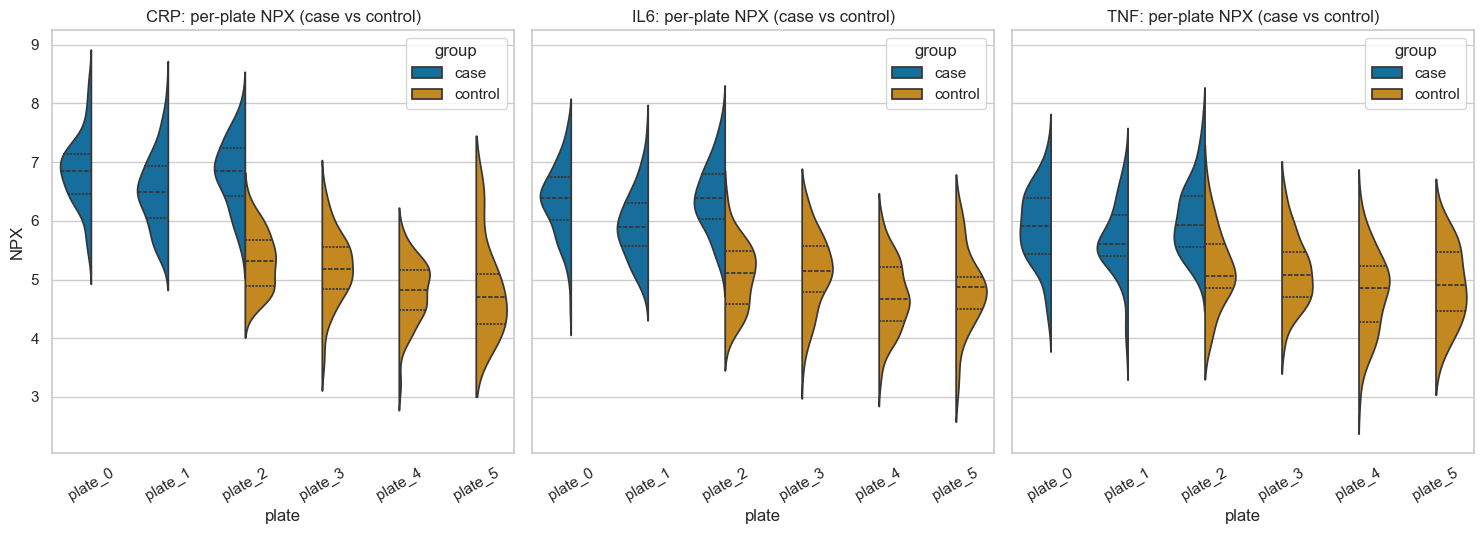

In [8]:
subset = (
    df.filter(pl.col("protein_id").is_in(["CRP", "IL6", "TNF"]))
      .to_pandas()
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5), sharey=True)
for ax, prot in zip(axes, ["CRP", "IL6", "TNF"]):
    sub = subset[subset["protein_id"] == prot]
    sns.violinplot(
        data=sub, x="plate_id", y="npx", hue="group",
        split=True, inner="quartile", ax=ax, palette="colorblind",
        density_norm="width",
    )
    ax.set_title(f"{prot}: per-plate NPX (case vs control)")
    ax.set_xlabel("plate")
    ax.set_ylabel("NPX")
    ax.tick_params(axis="x", rotation=30)

fig.tight_layout()
plt.show()

## 6. Sample-level dimensionality reduction (PCA + UMAP)

Pivot long -> wide (`sample` x `protein`), impute missing NPX with the
per-protein median (the standard Olink convention), then run PCA and UMAP.
Cases are expected to separate along the three injected-biomarker axes.

In [9]:
wide = (
    df.pivot(values="npx", index="sample_id", on="protein_id",
             aggregate_function="first")
      .sort("sample_id")
)
# Per-protein median imputation.
imputed = wide.with_columns([
    pl.col(col).fill_null(pl.col(col).median())
    for col in wide.columns if col != "sample_id"
])
# Sample-level group labels.
sample_groups = (
    df.group_by("sample_id").agg(group=pl.col("group").first())
      .sort("sample_id")
)
X = imputed.drop("sample_id").to_numpy()
y = sample_groups["group"].to_numpy()
print(f"sample x protein matrix: {X.shape}")
print(f"label counts           : case={int((y == 'case').sum())}, "
      f"control={int((y == 'control').sum())}")

sample x protein matrix: (500, 50)
label counts           : case=250, control=250


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


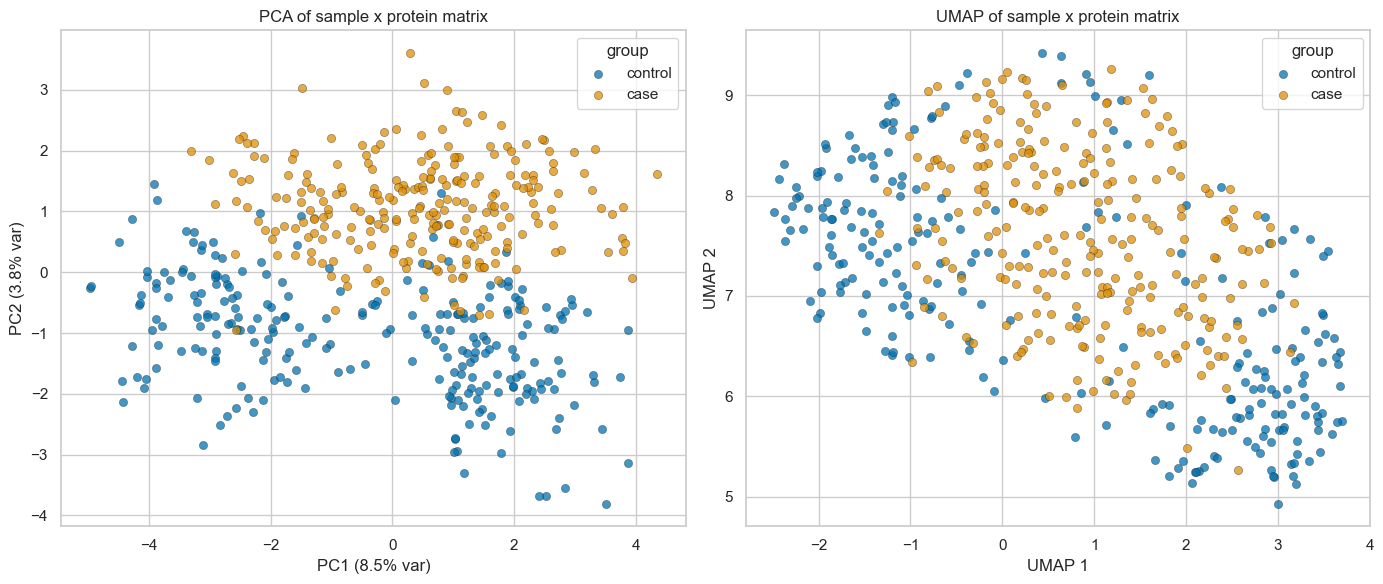

In [10]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import umap

Xz = StandardScaler().fit_transform(X)
pca = PCA(n_components=2, random_state=RNG_SEED)
pcs = pca.fit_transform(Xz)
umap_model = umap.UMAP(n_components=2, random_state=RNG_SEED, n_neighbors=15,
                       min_dist=0.1)
emb = umap_model.fit_transform(Xz)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 6))
palette = dict(zip(["control", "case"], sns.color_palette("colorblind", 2)))
for grp, color in palette.items():
    mask = y == grp
    axL.scatter(pcs[mask, 0], pcs[mask, 1], c=[color], label=grp, alpha=0.75,
                edgecolor="k", linewidth=0.3, s=35)
    axR.scatter(emb[mask, 0], emb[mask, 1], c=[color], label=grp, alpha=0.75,
                edgecolor="k", linewidth=0.3, s=35)
axL.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)")
axL.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)")
axL.set_title("PCA of sample x protein matrix")
axL.legend(title="group")
axR.set_xlabel("UMAP 1")
axR.set_ylabel("UMAP 2")
axR.set_title("UMAP of sample x protein matrix")
axR.legend(title="group")
fig.tight_layout()
plt.show()

## 7. Protein-protein correlation

Pairwise Pearson correlations for the 25 most-expressed proteins, ordered by
hierarchical clustering. Injected biomarkers (CRP, IL6, TNF) are expected to
cluster together because every case sample shifts all three simultaneously.

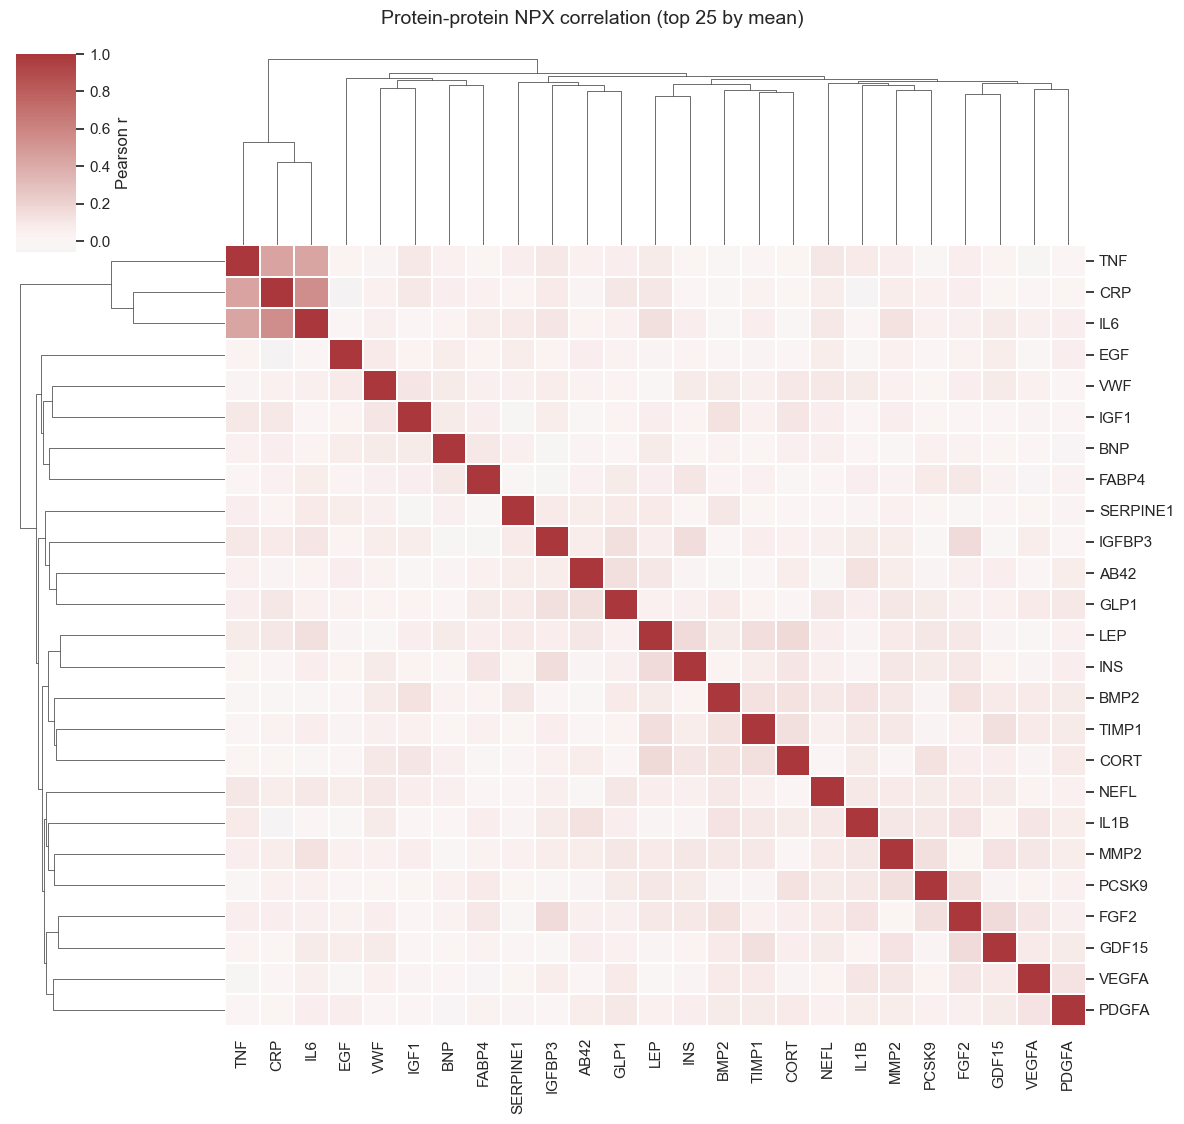

In [11]:
means = (
    df.group_by("protein_id").agg(mean_npx=pl.col("npx").mean())
      .sort("mean_npx", descending=True).head(25)["protein_id"].to_list()
)
wide_top = imputed.select(["sample_id", *means]).drop("sample_id").to_numpy()
corr = np.corrcoef(wide_top.T)

g = sns.clustermap(
    corr, cmap="vlag", center=0, xticklabels=means, yticklabels=means,
    figsize=(12, 11), linewidths=0.1, cbar_kws={"label": "Pearson r"},
)
g.fig.suptitle("Protein-protein NPX correlation (top 25 by mean)",
               fontsize=14, y=1.02)
plt.show()

## 8. Case vs control differential expression

Per-protein Welch t-test of case vs control NPX. The volcano plot shows the
mean NPX delta on the x axis and `-log10(p)` on the y axis. The three
manually-injected biomarkers (CRP, IL6, TNF) should sit in the upper-right
corner (positive delta, small p).

In [12]:
from scipy import stats as sstats

records = []
for prot in panel.proteins:
    sub = df.filter(pl.col("protein_id") == prot)
    case_vals = sub.filter(pl.col("group") == "case")["npx"].to_numpy()
    ctrl_vals = sub.filter(pl.col("group") == "control")["npx"].to_numpy()
    if case_vals.size < 3 or ctrl_vals.size < 3:
        continue
    delta = float(case_vals.mean() - ctrl_vals.mean())
    t, p = sstats.ttest_ind(case_vals, ctrl_vals, equal_var=False)
    records.append({"protein": prot, "delta": delta,
                    "neg_log10_p": -np.log10(max(float(p), 1e-300))})
volc = pl.DataFrame(records).sort("neg_log10_p", descending=True)
volc.head(10)

protein,delta,neg_log10_p
str,f64,f64
"""CRP""",1.675523,109.558062
"""IL6""",1.257665,73.416442
"""TNF""",0.878712,40.838176
"""ADIPOQ""",0.159276,2.149671
"""PSA""",0.131094,1.616747
"""IL1B""",-0.098993,1.216589
"""IFNG""",0.105199,1.17137
"""LEP""",0.098148,1.130072
"""AFP""",0.090535,0.874606


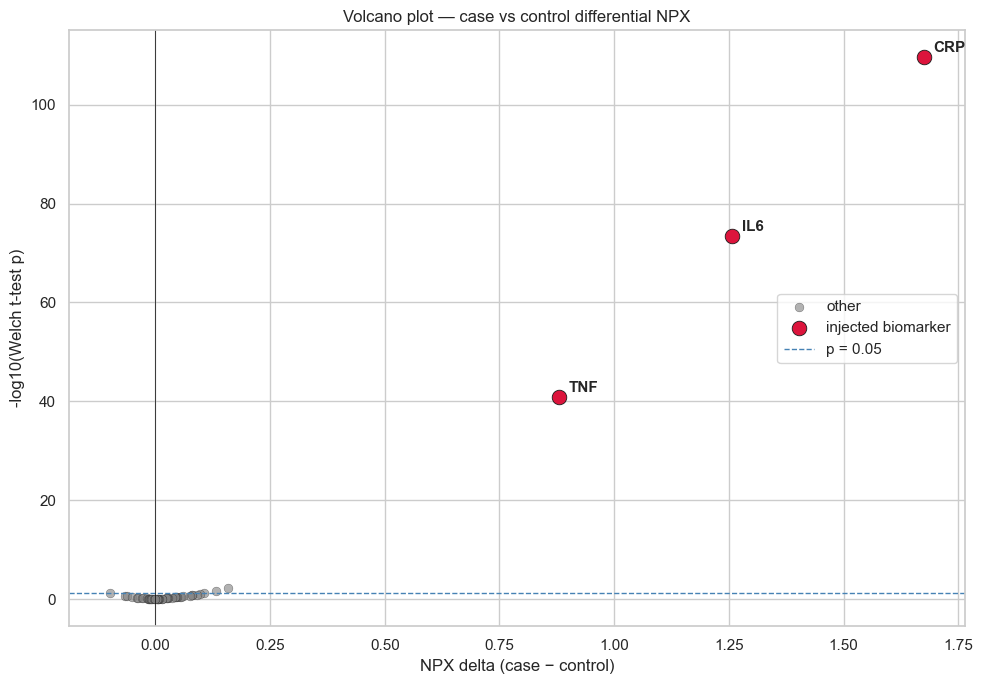

In [13]:
fig, ax = plt.subplots(figsize=(10, 7))
vp = volc.to_pandas()
injected = {"CRP", "IL6", "TNF"}
is_inj = vp["protein"].isin(injected)

ax.scatter(vp.loc[~is_inj, "delta"], vp.loc[~is_inj, "neg_log10_p"],
           color="grey", alpha=0.6, s=40, edgecolor="k", linewidth=0.3,
           label="other")
ax.scatter(vp.loc[is_inj, "delta"], vp.loc[is_inj, "neg_log10_p"],
           color="crimson", s=110, edgecolor="k", linewidth=0.6,
           label="injected biomarker")
for _, row in vp[is_inj].iterrows():
    ax.annotate(row["protein"], (row["delta"], row["neg_log10_p"]),
                xytext=(7, 4), textcoords="offset points", fontsize=11,
                fontweight="bold")
ax.axhline(-np.log10(0.05), color="steelblue", linestyle="--", linewidth=1,
           label="p = 0.05")
ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlabel("NPX delta (case − control)")
ax.set_ylabel("-log10(Welch t-test p)")
ax.set_title("Volcano plot — case vs control differential NPX")
ax.legend()
fig.tight_layout()
plt.show()

## 9. Parquet round-trip

[`write_olink_parquet`](../synthlab/olink.py) and
[`load_olink_parquet`](../synthlab/olink.py) are the canonical on-disk
serialisation entrypoints — snappy-compressed, schema-validated.

In [14]:
import pathlib
import tempfile

from synthlab import load_olink_parquet, write_olink_parquet

tmp = pathlib.Path(tempfile.mkdtemp()) / "olink_demo.parquet"
write_olink_parquet(df, tmp)
round_trip = load_olink_parquet(tmp)
assert df.equals(round_trip), "round-trip mismatch"
print(f"wrote {tmp}")
print(f"size : {tmp.stat().st_size // 1024} KB")
print(f"rows : {round_trip.height:,}")

wrote /var/folders/fm/7t4z124s3kz76r077_dfn7m80000gn/T/tmp5rx35d9o/olink_demo.parquet
size : 196 KB
rows : 23,737


## 10. Disease-conditional generation

So far we've hand-picked the three biomarkers (CRP, IL6, TNF) and their
effect sizes. In practice users want to **reuse published, source-cited
effect sizes** per disease — exactly what
[`synthlab.load_disease_effect_catalog`](../synthlab/olink.py) exposes.

The bundled CSV
[`synthlab/data/olink_disease_effects.csv`](../synthlab/data/olink_disease_effects.csv)
captures per-disease protein log2-NPX shifts from published plasma-proteomics
studies — each row cites a real DOI. Coverage at PR-time (see [PR
#TODO](https://github.com/bschilder/synthlab/pulls)):

- **T2D**: 8 proteins — [Sun et al. 2023 UKB-PPP](https://doi.org/10.1038/s41586-023-06592-6)
- **CAD**: 7 proteins — [Williams et al. 2022 Sci Transl Med](https://doi.org/10.1126/scitranslmed.abj9625) + [Eldjarn et al. 2023 deCODE](https://doi.org/10.1038/s41586-023-06563-x)
- **Cancer (broad)**: 6 proteins — [Cohen et al. 2018 CancerSEEK](https://doi.org/10.1126/science.aar3247)
- **BRCA hereditary**: 4 proteins, null-hypothesis placeholders from [Ahn et al. 2021](https://doi.org/10.3390/cancers13102300)
- **Alzheimer's**: 5 proteins — [Guo et al. 2024 Nat Aging](https://doi.org/10.1038/s43587-023-00565-0)
- **CKD**: 6 proteins — [Dubin et al. 2023 Nat Comm](https://doi.org/10.1038/s41467-023-41642-7)
- **IBD**: 7 proteins — [Hu et al. 2025 Nat Comm UKB-PPP](https://doi.org/10.1038/s41467-025-57879-3)

Load the catalog and inspect what's available:

In [15]:
from synthlab import load_disease_effect_catalog

catalog = load_disease_effect_catalog()
print(f"registered diseases ({len(catalog.diseases())}):")
for d in catalog.diseases():
    n = len(catalog.proteins_for(d))
    print(f"  {d:<18s} -> {n} proteins")

registered diseases (7):
  Alzheimer          -> 5 proteins
  BRCA_hereditary    -> 3 proteins
  CAD                -> 7 proteins
  CKD                -> 6 proteins
  Cancer_broad       -> 6 proteins
  IBD                -> 7 proteins
  T2D                -> 8 proteins


In [16]:
# Peek at the raw catalog rows for T2D.
catalog.effects.filter(pl.col("disease") == "T2D").select(
    ["protein_uniprot", "delta_npx", "se_delta", "evidence_strength", "source"]
)

protein_uniprot,delta_npx,se_delta,evidence_strength,source
str,f64,f64,str,str
"""IGFBP2""",-0.45,0.18,"""strong""","""Sun et al. 2023 UKB-PPP (N=54,…"
"""LEP""",0.8,0.25,"""strong""","""Sun et al. 2023 UKB-PPP (N=54,…"
"""ADIPOQ""",-0.6,0.2,"""strong""","""Sun et al. 2023 UKB-PPP (N=54,…"
"""IGFBP1""",-0.7,0.3,"""moderate""","""Sun et al. 2018 INTERVAL (N=3,…"
"""IL6""",0.3,0.2,"""moderate""","""Sun et al. 2023 UKB-PPP (N=54,…"
"""CRP""",0.35,0.2,"""strong""","""Sun et al. 2023 UKB-PPP (N=54,…"
"""GDF15""",0.55,0.22,"""strong""","""Sun et al. 2023 UKB-PPP (N=54,…"
"""TNF""",0.2,0.25,"""moderate""","""Sun et al. 2023 UKB-PPP (N=54,…"


### 10.1 3-group cohort (T2D / CAD / baseline) using catalog effects

We'll simulate 300 subjects per group. The panel is a uniform 5.0-NPX
baseline covering every catalog protein; LOD is set far below baseline so
we can cleanly recover the injected means.

In [17]:
from synthlab import OlinkPanelConfig
from synthlab import simulate_olink_npx

# Build a panel from all proteins referenced in the catalog.
catalog_proteins = tuple(catalog.effects["protein_uniprot"].unique().to_list())
disease_panel = OlinkPanelConfig(
    name="disease_catalog_panel",
    proteins=catalog_proteins,
    mean={p: 5.0 for p in catalog_proteins},
    sd={p: 0.5 for p in catalog_proteins},
    lod={p: -1000.0 for p in catalog_proteins},  # disable LOD drop for clean recovery
)
effects = catalog.effects_for(["T2D", "CAD"])

N_PER = 300
assignments = ["T2D"] * N_PER + ["CAD"] * N_PER + ["baseline"] * N_PER
cfg = OlinkSimConfig(
    n_samples=len(assignments),
    panel=disease_panel,
    group_effects=effects,
    group_assignments=assignments,
    missingness="none",
    qc_warn_rate=0.0,
    plate_effect_sd=0.0,
    seed=RNG_SEED,
)
df_catalog = simulate_olink_npx(cfg)
print(f"rows      : {df_catalog.height:,}")
print(f"groups    : {df_catalog['group'].value_counts().to_dict(as_series=False)}")
print(f"proteins  : {len(catalog_proteins)}")

rows      : 23,400
groups    : {'group': ['T2D', 'CAD', 'baseline'], 'count': [7800, 7800, 7800]}
proteins  : 26


### 10.2 Top-5 per-disease delta NPX — catalog vs empirical

Grouped bar chart: for each disease, show the top-5 absolute delta-NPX
proteins according to the catalog, side-by-side with the empirical case -
baseline mean shift from the simulation.

In [18]:
# Catalog top-5 deltas per disease (absolute magnitude).
top5_records = []
for dname in ["T2D", "CAD"]:
    rows = (
        catalog.effects.filter(pl.col("disease") == dname)
        .sort(pl.col("delta_npx").abs(), descending=True)
        .head(5)
    )
    for r in rows.iter_rows(named=True):
        prot = r["protein_uniprot"]
        # empirical delta from simulation
        case_mean = df_catalog.filter(
            (pl.col("protein_id") == prot) & (pl.col("group") == dname)
        )["npx"].mean()
        base_mean = df_catalog.filter(
            (pl.col("protein_id") == prot) & (pl.col("group") == "baseline")
        )["npx"].mean()
        top5_records.append({
            "disease": dname,
            "protein": prot,
            "catalog_delta": float(r["delta_npx"]),
            "empirical_delta": float(case_mean - base_mean),
        })
top5_df = pl.DataFrame(top5_records)
top5_df

disease,protein,catalog_delta,empirical_delta
str,str,f64,f64
"""T2D""","""LEP""",0.8,0.824616
"""T2D""","""IGFBP1""",-0.7,-0.733683
"""T2D""","""ADIPOQ""",-0.6,-0.703181
"""T2D""","""GDF15""",0.55,0.45455
"""T2D""","""IGFBP2""",-0.45,-0.492851
"""CAD""","""GDF15""",0.7,0.605253
"""CAD""","""NPPB""",0.55,0.538274
"""CAD""","""MMP12""",0.5,0.452784
"""CAD""","""TNNI3""",0.45,0.417845


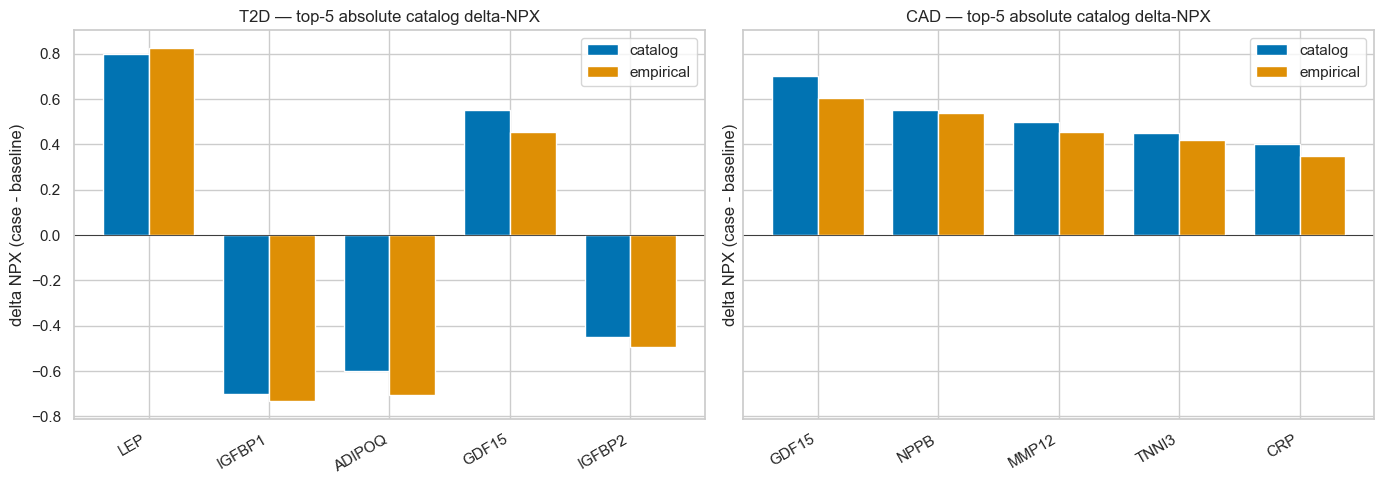

In [19]:
import pandas as pd

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, dname in zip(axes, ["T2D", "CAD"]):
    sub = top5_df.filter(pl.col("disease") == dname).to_pandas()
    x = np.arange(len(sub))
    width = 0.38
    ax.bar(x - width / 2, sub["catalog_delta"], width,
           label="catalog", color=sns.color_palette("colorblind")[0])
    ax.bar(x + width / 2, sub["empirical_delta"], width,
           label="empirical", color=sns.color_palette("colorblind")[1])
    ax.set_xticks(x)
    ax.set_xticklabels(sub["protein"], rotation=30, ha="right")
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_title(f"{dname} — top-5 absolute catalog delta-NPX")
    ax.set_ylabel("delta NPX (case - baseline)")
    ax.legend()
fig.tight_layout()
plt.show()

### 10.3 Catalog-vs-empirical consistency check

Scatter of catalog delta vs empirical simulation delta across every
(disease, protein) row used. Points should hug the identity line (y = x);
deviations reflect Monte-Carlo sampling noise at 300 samples per group.

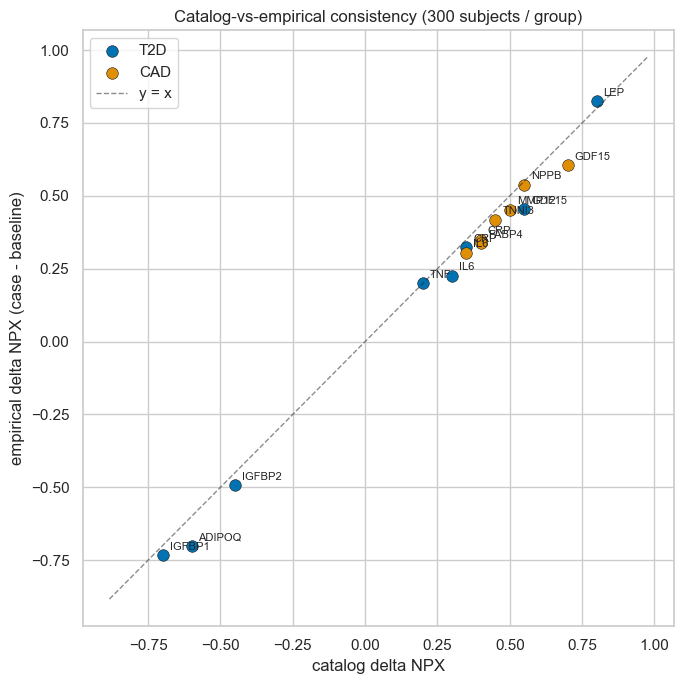

In [20]:
records = []
for r in catalog.effects.filter(pl.col("disease").is_in(["T2D", "CAD"])).iter_rows(
    named=True
):
    dname = r["disease"]
    prot = r["protein_uniprot"]
    expected = float(r["delta_npx"])
    if expected == 0.0:
        continue
    case_mean = df_catalog.filter(
        (pl.col("protein_id") == prot) & (pl.col("group") == dname)
    )["npx"].mean()
    base_mean = df_catalog.filter(
        (pl.col("protein_id") == prot) & (pl.col("group") == "baseline")
    )["npx"].mean()
    records.append({"disease": dname, "protein": prot,
                    "catalog_delta": expected,
                    "empirical_delta": float(case_mean - base_mean)})
consistency = pl.DataFrame(records)

fig, ax = plt.subplots(figsize=(7, 7))
palette = dict(zip(["T2D", "CAD"], sns.color_palette("colorblind", 2)))
for dname, color in palette.items():
    sub = consistency.filter(pl.col("disease") == dname).to_pandas()
    ax.scatter(sub["catalog_delta"], sub["empirical_delta"],
               s=70, color=color, edgecolor="k", linewidth=0.4,
               label=dname)
    for _, row in sub.iterrows():
        ax.annotate(row["protein"], (row["catalog_delta"], row["empirical_delta"]),
                    xytext=(5, 4), textcoords="offset points", fontsize=8)
lo = float(consistency.select(pl.col("catalog_delta").min(),
                               pl.col("empirical_delta").min())
                      .min_horizontal()[0]) - 0.15
hi = float(consistency.select(pl.col("catalog_delta").max(),
                               pl.col("empirical_delta").max())
                      .max_horizontal()[0]) + 0.15
ax.plot([lo, hi], [lo, hi], "k--", linewidth=1, alpha=0.5, label="y = x")
ax.set_xlabel("catalog delta NPX")
ax.set_ylabel("empirical delta NPX (case - baseline)")
ax.set_title("Catalog-vs-empirical consistency (300 subjects / group)")
ax.legend()
fig.tight_layout()
plt.show()

## 11. Where to next

The simulator is deliberately minimal — the scope of [PR
#2](https://github.com/bschilder/synthlab/pull/2) is "smallest viable NPX
simulator with LOD + plates + group effects" and the follow-up adds a
curated effect-size catalog. Remaining roadmap:

- **Full MAR missingness**: model missingness as a function of sample-level
  covariates (age, QC batch) rather than aliasing to MCAR.
- **Multi-factor batch effects**: plate x run x operator, with per-factor
  variance components.
- **Panel-version LOD bridging**: Olink Explore HT vs Explore 3072 have
  different LOD distributions; a bridging mode should allow cross-panel
  simulation.
- **PEA dilution / matrix effects**: the real [PEA
  assay](https://olink.com/technology/proximity-extension-assay) has a
  noise model that scales with dilution; currently we use a flat per-protein
  sigma.
- **Covariate-adjusted catalog effects**: age / sex / BMI-conditional
  deltas instead of the current marginal means.
- **Longitudinal effects**: time-to-event modulation of the catalog deltas
  for incidence-cohort simulations.

Tracking discussion in [PR #2](https://github.com/bschilder/synthlab/pull/2);
please open issues for missing features.